<a href="https://colab.research.google.com/github/Tahir-MD/SoftGrowTech_WhetherAnalysis/blob/main/SoftGrowTech_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv('weatherHistory.csv')
print(df.head())
print(df.info())
print(df.describe())

                  Formatted_Date        Summary Precip_Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent_Temperature_C  Humidity  Wind Speed (km/h)  \
0                7.388889      0.89            14.1197   
1                7.227778      0.86            14.2646   
2                9.377778      0.89             3.9284   
3                5.944444      0.83            14.1036   
4                6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                     251          15.8263           0               1015.13   
1         

In [3]:
print(df.isnull().sum())
df = df.dropna()
print(df.shape)

Formatted_Date              0
Summary                     0
Precip_Type               517
Temperature (C)             0
Apparent_Temperature_C      0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64
(95936, 12)


In [6]:
df['Formatted_Date'] = pd.to_datetime(df['Formatted_Date'], utc=True)
df['Year'] = df['Formatted_Date'].dt.year
df['Month'] = df['Formatted_Date'].dt.month
df['Day'] = df['Formatted_Date'].dt.day

In [7]:
avg_temp = df['Temperature (C)'].mean()
max_temp = df['Temperature (C)'].max()
min_temp = df['Temperature (C)'].min()
print(f"Average Temperature: {avg_temp:.2f}°C")
print(f"Maximum Temperature: {max_temp:.2f}°C")
print(f"Minimum Temperature: {min_temp:.2f}°C")

Average Temperature: 11.94°C
Maximum Temperature: 39.91°C
Minimum Temperature: -21.82°C


In [8]:
avg_humidity = df['Humidity'].mean()
max_humidity = df['Humidity'].max()
min_humidity = df['Humidity'].min()
print(f"Average Humidity: {avg_humidity:.2f}")
print(f"Maximum Humidity: {max_humidity:.2f}")
print(f"Minimum Humidity: {min_humidity:.2f}")

Average Humidity: 0.73
Maximum Humidity: 1.00
Minimum Humidity: 0.00


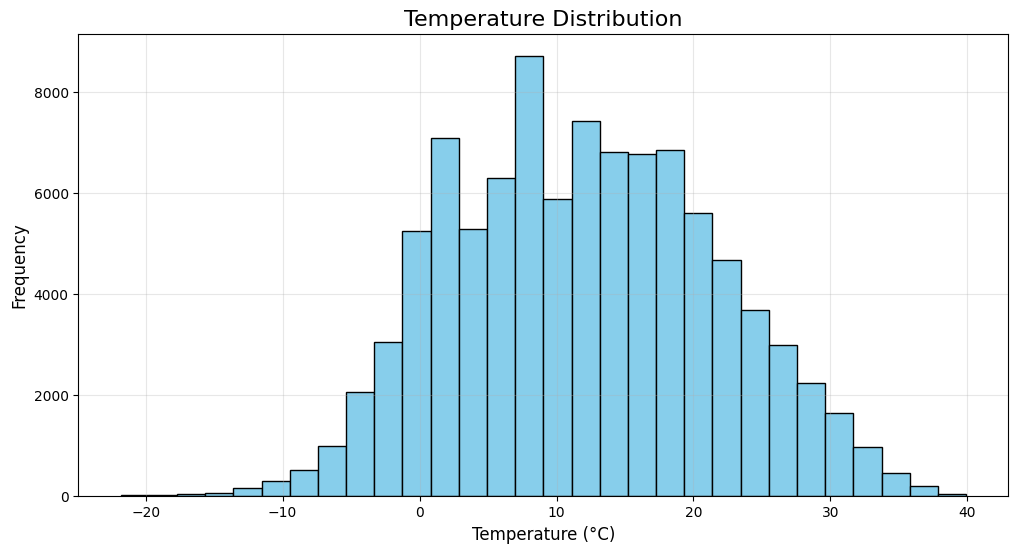

In [9]:
plt.figure(figsize=(12, 6))
plt.hist(df['Temperature (C)'], bins=30, color='skyblue', edgecolor='black')
plt.title('Temperature Distribution', fontsize=16)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

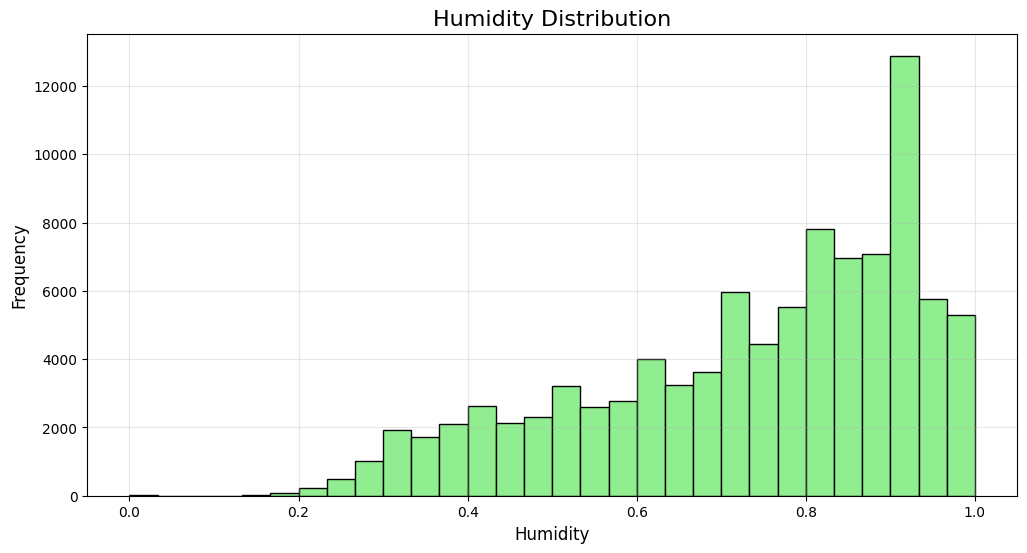

In [10]:
plt.figure(figsize=(12, 6))
plt.hist(df['Humidity'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Humidity Distribution', fontsize=16)
plt.xlabel('Humidity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

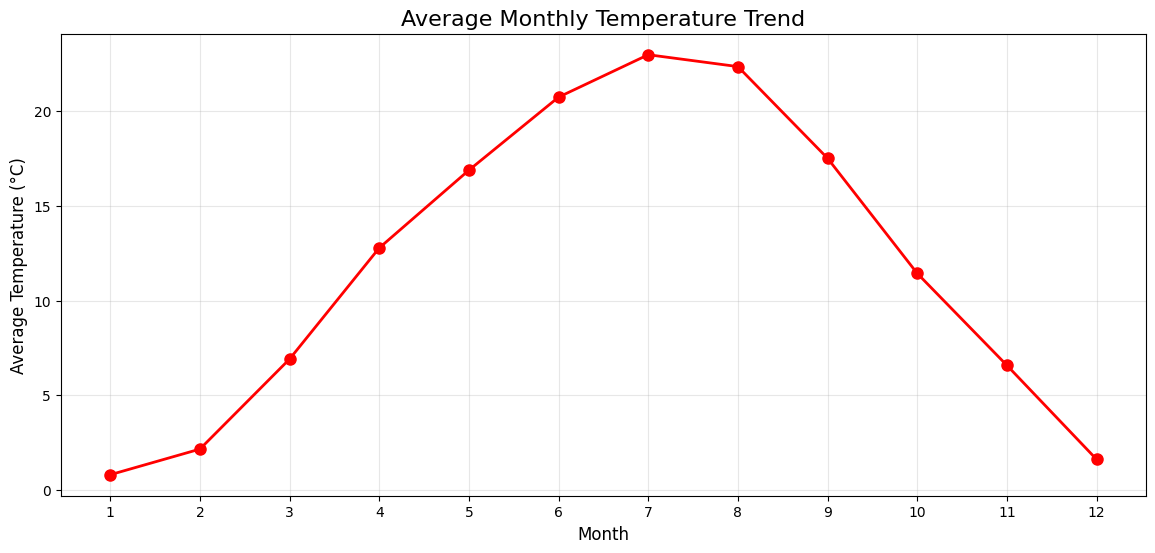

In [11]:
monthly_temp = df.groupby('Month')['Temperature (C)'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp['Month'], monthly_temp['Temperature (C)'],
         marker='o', color='red', linewidth=2, markersize=8)
plt.title('Average Monthly Temperature Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

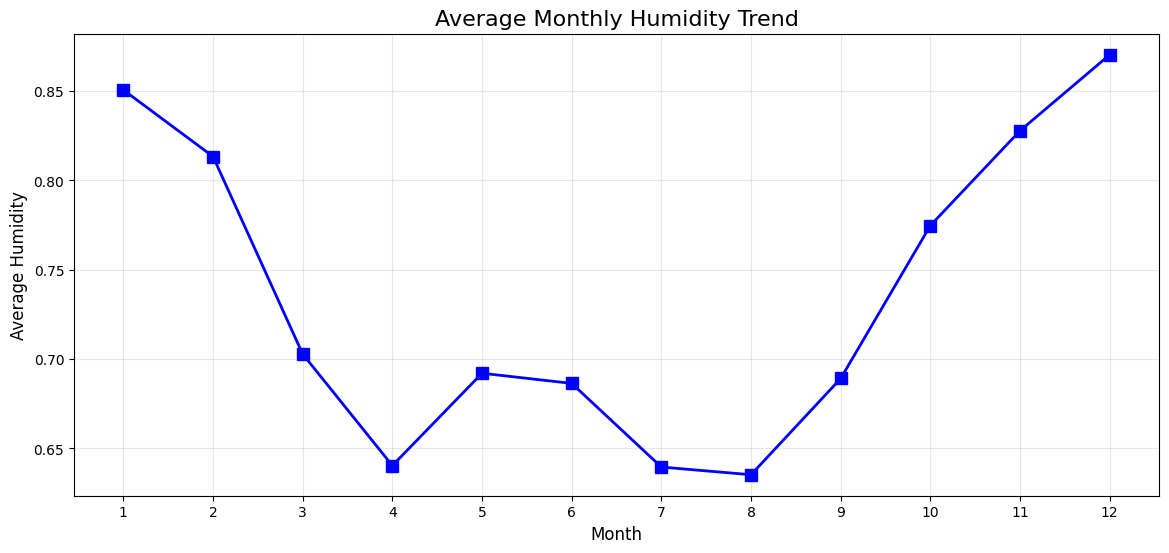

In [12]:
monthly_humidity = df.groupby('Month')['Humidity'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(monthly_humidity['Month'], monthly_humidity['Humidity'],
         marker='s', color='blue', linewidth=2, markersize=8)
plt.title('Average Monthly Humidity Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Humidity', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

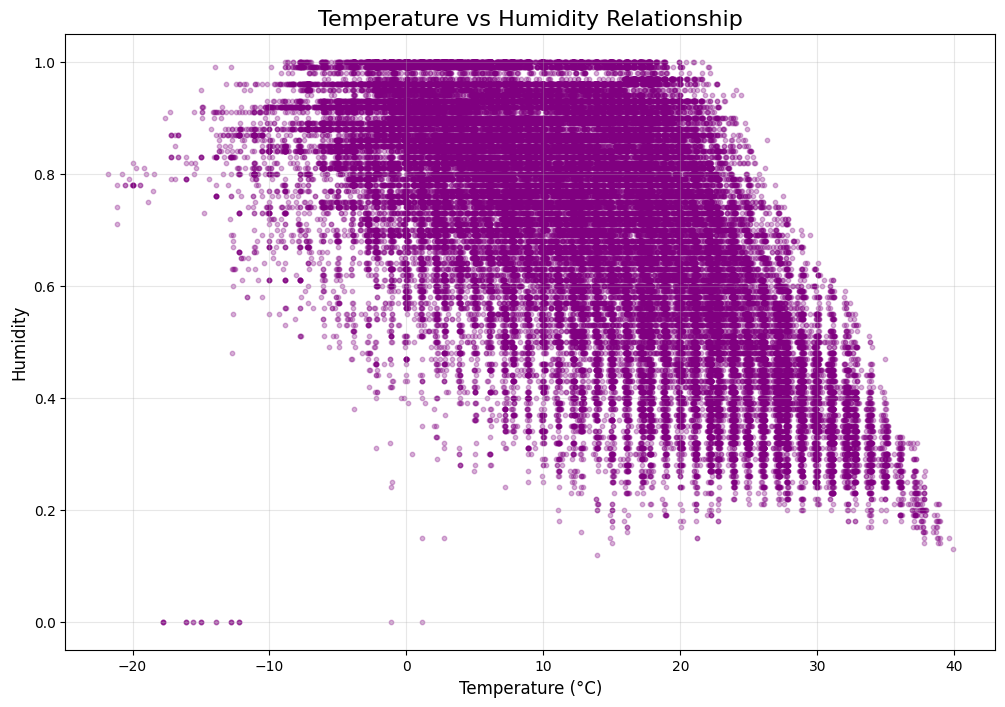

In [13]:
plt.figure(figsize=(12, 8))
plt.scatter(df['Temperature (C)'], df['Humidity'],
            alpha=0.3, c='purple', s=10)
plt.title('Temperature vs Humidity Relationship', fontsize=16)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Humidity', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

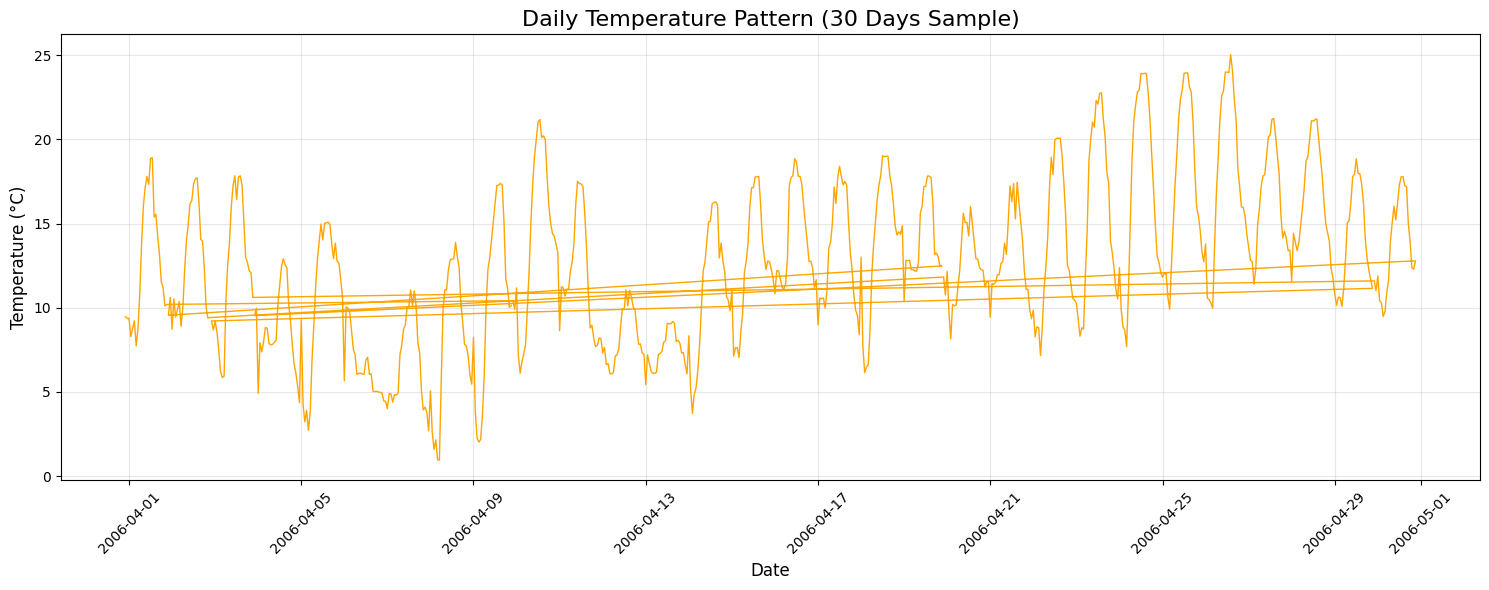

In [15]:
daily_sample = df.head(720)
plt.figure(figsize=(15, 6))
plt.plot(daily_sample['Formatted_Date'], daily_sample['Temperature (C)'],
         color='orange', linewidth=1)
plt.title('Daily Temperature Pattern (30 Days Sample)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

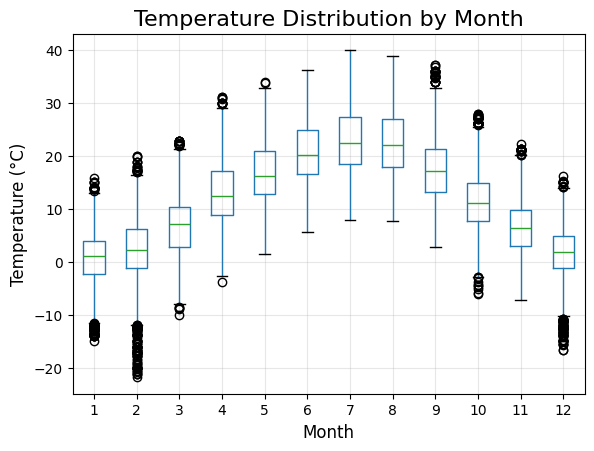

In [16]:
plt.figure(figsize=(14, 8))
df.boxplot(column='Temperature (C)', by='Month')
plt.title('Temperature Distribution by Month', fontsize=16)
plt.suptitle('')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1400x800 with 0 Axes>

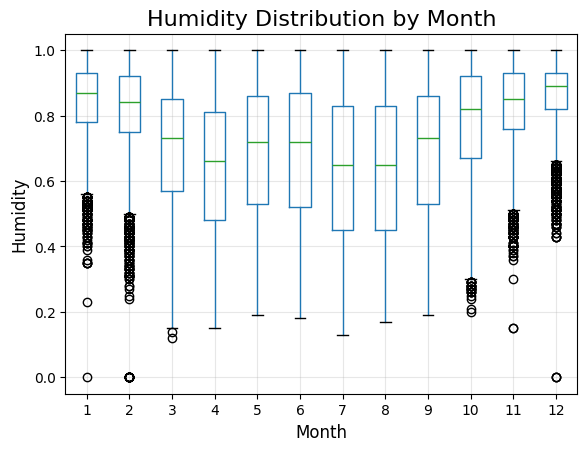

In [17]:
plt.figure(figsize=(14, 8))
df.boxplot(column='Humidity', by='Month')
plt.title('Humidity Distribution by Month', fontsize=16)
plt.suptitle('')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Humidity', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

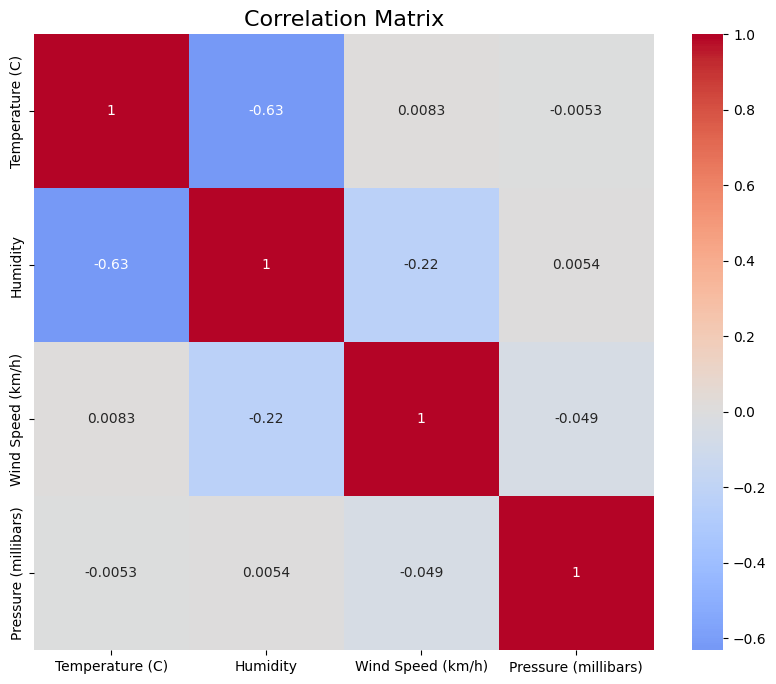

In [18]:
numeric_cols = df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
                   'Pressure (millibars)']]
correlation = numeric_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

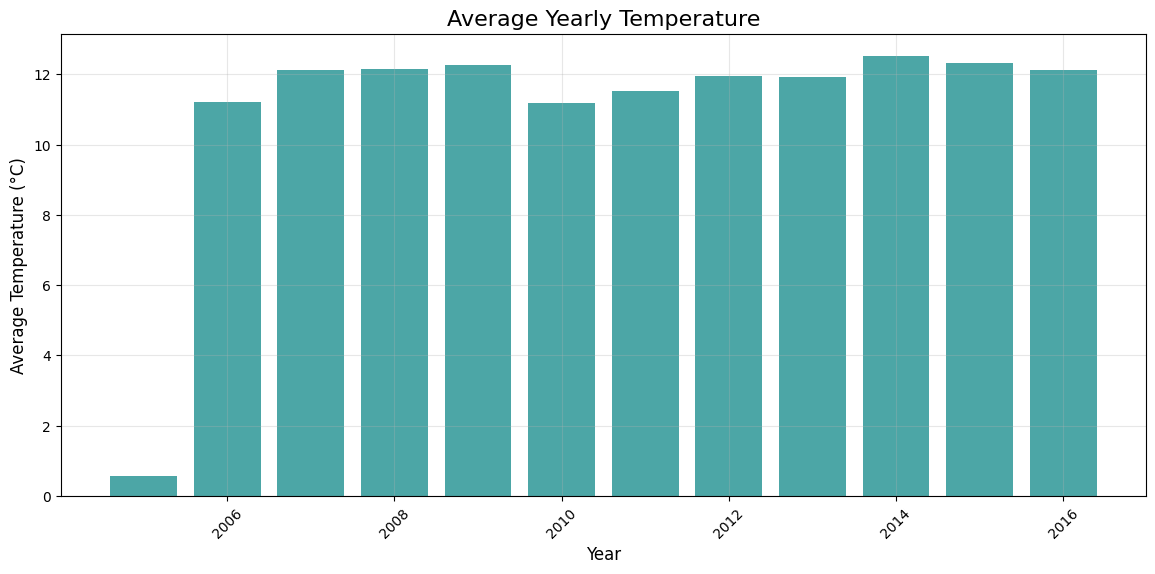

In [19]:
yearly_temp = df.groupby('Year')['Temperature (C)'].mean().reset_index()
plt.figure(figsize=(14, 6))
plt.bar(yearly_temp['Year'], yearly_temp['Temperature (C)'],
        color='teal', alpha=0.7)
plt.title('Average Yearly Temperature', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
print("=" * 50)
print("WEATHER DATA ANALYSIS SUMMARY")
print("=" * 50)
print(f"1. Dataset contains {len(df)} weather records")
print(f"2. Temperature ranges from {min_temp:.1f}°C to {max_temp:.1f}°C")
print(f"3. Hottest month: Month {monthly_temp.loc[monthly_temp['Temperature (C)'].idxmax(), 'Month']} with {monthly_temp['Temperature (C)'].max():.1f}°C")
print(f"4. Coldest month: Month {monthly_temp.loc[monthly_temp['Temperature (C)'].idxmin(), 'Month']} with {monthly_temp['Temperature (C)'].min():.1f}°C")
print(f"5. Humidity ranges from {min_humidity:.2f} to {max_humidity:.2f}")
print(f"6. Highest humidity month: Month {monthly_humidity.loc[monthly_humidity['Humidity'].idxmax(), 'Month']}")
print(f"7. Correlation between temperature and humidity: {correlation.loc['Temperature (C)', 'Humidity']:.3f}")
print("=" * 50)

WEATHER DATA ANALYSIS SUMMARY
1. Dataset contains 95936 weather records
2. Temperature ranges from -21.8°C to 39.9°C
3. Hottest month: Month 7 with 23.0°C
4. Coldest month: Month 1 with 0.8°C
5. Humidity ranges from 0.00 to 1.00
6. Highest humidity month: Month 12
7. Correlation between temperature and humidity: -0.632
